In [70]:
import numpy as np
import pandas as pd
import datetime
from datetime import datetime
from pathlib import Path
import os
from epiweeks import Week
from datetime import date, timedelta
import seaborn as sns
import matplotlib.pyplot as plt
from scorepi import *

import warnings
warnings.filterwarnings('ignore')

# Trajectories

In [47]:
folder_path = './data/trajectories/raw_trajectories/'
all_files = os.listdir(folder_path)
csv_files = [file for file in all_files if file.endswith('.csv.gz')]

locations = pd.read_csv('./data/location_codebook.csv').drop(columns='ISO')

df_list = []
TODAY = datetime.now()

for filename in csv_files:
    file_path = os.path.join(folder_path, filename)
    df = pd.read_csv(file_path)
    
    df = df[['primary_id', 'sim_id', 'population', 'date', 'hospitalizations']].rename(columns={'primary_id':'location_id',
                                 'sim_id':'run_id','population':'location_name_epydemix', 'hospitalizations':'value'})

    df['date'] = pd.to_datetime(df['date'])
    df['epiweek'] = int(filename[13:19])
    
    reference_date = pd.to_datetime(Week(int(filename[13:17]), int(filename[17:19])).enddate())
    df['reference_date'] = reference_date
    
    df = df[(df.date>=reference_date)  ]

    
    # filter out states that we dont submit for a given reference date
    if reference_date == pd.to_datetime('2025-11-29'):
        df = df[~df.location_name_epydemix.isin(['United_States_Hawaii', 'United_States_Colorado',
                                                'United_States_Arkansas'])]
    elif reference_date == pd.to_datetime('2025-12-20'):
        df = df[~df.location_name_epydemix.isin(['United_States_Hawaii', 'United_States_Connecticut',
                                                'United_States_Minnesota', 'United_States_Rhode_Island'])]
    elif reference_date == pd.to_datetime('2025-12-27'):
        df = df[~df.location_name_epydemix.isin(['United_States_Hawaii', 'United_States_Alaska',
                                                'United_States_Minnesota', ])]
    
    df['horizon'] = (df['date'] - df['reference_date']).dt.days//7
    
    df.to_csv(f'./data/trajectories/epystrain_trajectories_{str(reference_date)[0:10]}.csv', index=False)
    
    df_list.append(df)

if df_list:
    combined_df = pd.concat(df_list, ignore_index=True)
else:
    print("No CSV files found in the specified folder.")
    
    
combined_df = combined_df.merge(locations, on=['location_name_epydemix']).drop(columns=['location_name_epydemix',
                                  'location_id','location_abbreviation']).rename(columns={'location_code':'location'})

In [48]:
combined_df

,run_id,date,value,epiweek,reference_date,horizon,location_name,location
0,0,2025-12-27,32937.0,202552,2025-12-27,0,United States,US
1,0,2026-01-03,45622.0,202552,2025-12-27,1,United States,US
2,0,2026-01-10,54984.0,202552,2025-12-27,2,United States,US
3,0,2026-01-17,54883.0,202552,2025-12-27,3,United States,US
4,0,2026-01-24,46368.0,202552,2025-12-27,4,United States,US
...,...,...,...,...,...,...,...,...
7781995,999,2026-04-18,35.0,202548,2025-11-29,20,Minnesota,27
7781996,999,2026-04-25,27.0,202548,2025-11-29,21,Minnesota,27
7781997,999,2026-05-02,23.0,202548,2025-11-29,22,Minnesota,27
7781998,999,2026-05-09,24.0,202548,2025-11-29,23,Minnesota,27


In [17]:
def pull_surveillance_data():
    url = f"https://raw.githubusercontent.com/cdcepi/FluSight-forecast-hub/main/target-data/target-hospital-admissions.csv"
    return pd.read_csv(url, dtype={'location':str})


In [18]:
surv = pull_surveillance_data()

In [19]:
surv.to_csv('./data/target-hospital-admissions.csv')

# Calculate energy score

In [49]:
from numba import njit
@njit
def energyscore(X,y):
    # X is matrix of trajectories, y is observations
    ES = 0
    N = X.shape[0]
    for i in range(N):
        ES += np.sqrt(np.sum((X[i]-y)**2))/N
    for i in range(N):
        for j in range(N):
            ES -= np.sqrt(np.sum((X[i]-X[j])**2))/(2*N**2)
    return ES


In [50]:
@njit
def normalized_energyscore(X,y):
    # X is matrix of trajectories, y is observations
    ES = 0
    N = X.shape[0]
    for i in range(N):
        ES += np.sqrt(np.sum(((X[i]-y))**2))/N
    for i in range(N):
        for j in range(N):
            ES -= np.sqrt(np.sum(((X[i]-X[j]))**2))/(2*N**2)
    return ES/sum(y)

In [58]:
energyscoresdf = pd.DataFrame()

predictions_traj = combined_df.rename(columns={'date':'target_end_date'})
predictions_traj['target_end_date'] = pd.to_datetime(predictions_traj['target_end_date'])
predictions_traj['reference_date'] = pd.to_datetime(predictions_traj['reference_date'])

for ref_date in predictions_traj.reference_date.unique():
    for loc in predictions_traj.location.unique():
               
            ref_date = pd.to_datetime(ref_date)
            observations = pull_surveillance_data()
            observations['date'] = pd.to_datetime(observations['date'])

            predictionsfilt = predictions_traj[(predictions_traj.location == loc) & \
                     (predictions_traj.reference_date==ref_date) &(predictions_traj.target_end_date >= ref_date) &\
                     (predictions_traj.target_end_date<=observations.date.max()) &\
                     (predictions_traj.target_end_date<=pd.to_datetime((Week.fromdate(ref_date)+3).enddate()))]

            if len(predictionsfilt) == 0:
                print(f'no predictions for location {loc} for date {ref_date}')
                continue
        
            observations = observations[(observations['date'] >= ref_date) & \
                                        (observations['date'] <= predictionsfilt.target_end_date.max())]   

            
            #aggregate to weekly
            observations = observations.groupby(['location', pd.Grouper(key='date', freq='W-SAT')]).sum().reset_index()

            #transform to Observation object
            #observations = Observations(observations)

            #filter location
            observations = observations[observations['location'] == loc]


            y = np.array(observations.value)
            X = [np.array(predictionsfilt[predictionsfilt['run_id'] == i].value) for i in predictionsfilt['run_id'].unique()]

            ES = energyscore(np.array(X),y)
     

            newrow = pd.DataFrame({'location':loc, 'energyscore':ES, 'reference_date':ref_date}, index=[0])

            energyscoresdf = pd.concat([energyscoresdf, newrow])

energyscoresdf = energyscoresdf.reset_index()
energyscoresdf = energyscoresdf.drop(columns=['index'])   


#energyscoresdf = pd.merge(energyscoresdf, locations, how = 'inner', on = 'location')



no predictions for location 02 for date 2025-12-27 00:00:00
no predictions for location 15 for date 2025-12-27 00:00:00
no predictions for location 27 for date 2025-12-27 00:00:00
no predictions for location 09 for date 2025-12-20 00:00:00
no predictions for location 44 for date 2025-12-20 00:00:00
no predictions for location 15 for date 2025-12-20 00:00:00
no predictions for location 27 for date 2025-12-20 00:00:00
no predictions for location 05 for date 2025-11-29 00:00:00
no predictions for location 08 for date 2025-11-29 00:00:00
no predictions for location 15 for date 2025-11-29 00:00:00


In [59]:
energyscoresdf

,location,energyscore,reference_date
0,US,24067.785395,2025-12-27
1,01,725.337591,2025-12-27
2,04,196.709656,2025-12-27
3,05,261.138901,2025-12-27
4,06,532.472509,2025-12-27
...,...,...,...
349,54,68.656598,2025-11-29
350,55,239.094389,2025-11-29
351,56,14.504520,2025-11-29
352,02,22.191555,2025-11-29


In [61]:
normenergyscoresdf = pd.DataFrame()

predictions_traj = combined_df.rename(columns={'date':'target_end_date'})
predictions_traj['target_end_date'] = pd.to_datetime(predictions_traj['target_end_date'])
predictions_traj['reference_date'] = pd.to_datetime(predictions_traj['reference_date'])

for ref_date in predictions_traj.reference_date.unique():
    for loc in predictions_traj.location.unique():
               
            ref_date = pd.to_datetime(ref_date)
            observations = pull_surveillance_data()
            observations['date'] = pd.to_datetime(observations['date'])

            predictionsfilt = predictions_traj[(predictions_traj.location == loc) & \
                     (predictions_traj.reference_date==ref_date) &(predictions_traj.target_end_date >= ref_date) &\
                     (predictions_traj.target_end_date<=observations.date.max()) &\
                     (predictions_traj.target_end_date<=pd.to_datetime((Week.fromdate(ref_date)+3).enddate()))]

            if len(predictionsfilt) == 0:
                print(f'no predictions for location {loc} for date {ref_date}')
                continue
        
            observations = observations[(observations['date'] >= ref_date) & \
                                        (observations['date'] <= predictionsfilt.target_end_date.max())]   

            
            #aggregate to weekly
            observations = observations.groupby(['location', pd.Grouper(key='date', freq='W-SAT')]).sum().reset_index()

            #transform to Observation object
            #observations = Observations(observations)

            #filter location
            observations = observations[observations['location'] == loc]


            y = np.array(observations.value)
            X = [np.array(predictionsfilt[predictionsfilt['run_id'] == i].value) for i in predictionsfilt['run_id'].unique()]

            ES = normalized_energyscore(np.array(X),y)
     

            newrow = pd.DataFrame({'location':loc, 'energyscore':ES, 'reference_date':ref_date}, index=[0])

            normenergyscoresdf = pd.concat([normenergyscoresdf, newrow])

normenergyscoresdf = normenergyscoresdf.reset_index()
normenergyscoresdf = normenergyscoresdf.drop(columns=['index'])   


#energyscoresdf = pd.merge(energyscoresdf, locations, how = 'inner', on = 'location')



no predictions for location 02 for date 2025-12-27 00:00:00
no predictions for location 15 for date 2025-12-27 00:00:00
no predictions for location 27 for date 2025-12-27 00:00:00
no predictions for location 09 for date 2025-12-20 00:00:00
no predictions for location 44 for date 2025-12-20 00:00:00
no predictions for location 15 for date 2025-12-20 00:00:00
no predictions for location 27 for date 2025-12-20 00:00:00
no predictions for location 05 for date 2025-11-29 00:00:00
no predictions for location 08 for date 2025-11-29 00:00:00
no predictions for location 15 for date 2025-11-29 00:00:00


In [62]:
normenergyscoresdf = normenergyscoresdf.rename(columns={'energyscore':'energyscore_norm'})

In [63]:
normenergyscoresdf

,location,energyscore_norm,reference_date
0,US,0.230065,2025-12-27
1,01,0.559243,2025-12-27
2,04,0.219787,2025-12-27
3,05,0.402371,2025-12-27
4,06,0.130636,2025-12-27
...,...,...,...
349,54,0.572138,2025-11-29
350,55,0.386884,2025-11-29
351,56,0.207207,2025-11-29
352,02,0.303994,2025-11-29


In [64]:
ESall = energyscoresdf.merge(normenergyscoresdf)[['location', 'reference_date','energyscore', 'energyscore_norm']]

locations = combined_df[['location', 'location_name']].drop_duplicates()

ESall = ESall.merge(locations)

In [65]:
ESall.to_csv('./data/scores/epystrain_energyscore_dat.csv' , index=False)

Text(3.972222222222216, 0.5, 'Reference Date')

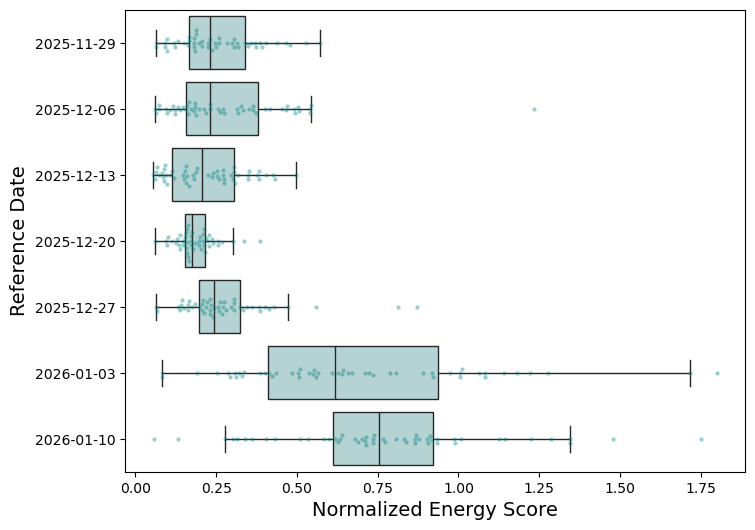

In [66]:
df = ESall.sort_values(by='reference_date')


fig, ax = plt.subplots(1,1,figsize=(8,6))
sns.boxplot(x='energyscore_norm', y='reference_date', data=df, orient='h',showfliers=False, color='teal')

for patch in ax.patches:
    r, gr, b, a = patch.get_facecolor()
    patch.set_facecolor((r, gr, b, .3))
    
sns.swarmplot(x='energyscore_norm', y='reference_date', data=df,color = 'teal',alpha = .4,size=3,
              orient="h")  


plt.xlabel('Normalized Energy Score', fontsize=14)
plt.ylabel('Reference Date', fontsize=14)

# Calculate WIS

In [71]:
wisdf_traj = pd.DataFrame()    

predictions_traj = combined_df.rename(columns={'date':'target_end_date'})
predictions_traj['target_end_date'] = pd.to_datetime(predictions_traj['target_end_date'])
predictions_traj['reference_date'] = pd.to_datetime(predictions_traj['reference_date'])

for ref_date in predictions_traj.reference_date.unique():
    for loc in predictions_traj.location.unique():

        ref_date = pd.to_datetime(ref_date)
        observations = pull_surveillance_data()
        observations['date'] = pd.to_datetime(observations['date'])

        predictionsfilt = predictions_traj[(predictions_traj.location == loc) & \
                 (predictions_traj.reference_date==ref_date) &(predictions_traj.target_end_date >= ref_date) &\
                 (predictions_traj.target_end_date<=observations.date.max()) &\
                 (predictions_traj.target_end_date<=pd.to_datetime((Week.fromdate(ref_date)+3).enddate()))]

        if len(predictionsfilt) == 0:
            print(f'no predictions for location {loc} for date {ref_date}')
            continue


        observations = observations[(observations['date'] >= ref_date) & \
                                        (observations['date'] <= predictionsfilt.target_end_date.max())]   

        #aggregate to weekly
        observations = observations.groupby(['location', pd.Grouper(key='date', freq='W-SAT')]).sum().reset_index()

        #filter location
        observations = observations[observations['location'] == loc]

        y = np.array(observations.value)
        X = np.array([np.array(predictionsfilt[predictionsfilt.run_id == i].value) \
                        for i in predictionsfilt.run_id.unique()])

        quantiles=[0.01,0.025,0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.60,
                    0.65,0.7,0.75,0.8,0.85,0.9,0.95,0.975,0.99]

        # get quantiles
        Q = np.quantile(X,quantiles,axis=0)

        # calculate WIS
        WIS = np.zeros(X.shape[1])

        for i in range(len(quantiles) // 2):
            interval_range = 100*(quantiles[-i-1]-quantiles[i])
            alpha = 1-(quantiles[-i-1]-quantiles[i])
            IS = interval_score(y,Q[i],Q[-i-1],interval_range)
            WIS += IS['interval_score']*alpha/2
        WIS += 0.5*np.abs(Q[len(quantiles) // 2] - y)

        WIS = np.mean(WIS) / (len(quantiles) // 2 + 0.5)

        # save into dataframe
        newrow = pd.DataFrame({'reference_date':ref_date, 'location':loc, 'WIS':WIS}, index=[0])

        wisdf_traj = pd.concat([wisdf_traj, newrow])


wisdf_traj = wisdf_traj.reset_index()
wisdf_traj = wisdf_traj.drop(columns=['index'])   


no predictions for location 02 for date 2025-12-27 00:00:00
no predictions for location 15 for date 2025-12-27 00:00:00
no predictions for location 27 for date 2025-12-27 00:00:00
no predictions for location 09 for date 2025-12-20 00:00:00
no predictions for location 44 for date 2025-12-20 00:00:00
no predictions for location 15 for date 2025-12-20 00:00:00
no predictions for location 27 for date 2025-12-20 00:00:00
no predictions for location 05 for date 2025-11-29 00:00:00
no predictions for location 08 for date 2025-11-29 00:00:00
no predictions for location 15 for date 2025-11-29 00:00:00


In [72]:
wisdf_traj

,reference_date,location,WIS
0,2025-12-27,US,9191.959531
1,2025-12-27,01,284.536511
2,2025-12-27,04,81.402313
3,2025-12-27,05,106.815683
4,2025-12-27,06,197.283194
...,...,...,...
349,2025-11-29,54,27.079364
350,2025-11-29,55,83.473110
351,2025-11-29,56,5.404979
352,2025-11-29,02,7.718909


In [73]:
wisdf_norm = pd.DataFrame()    

predictions_traj = combined_df.rename(columns={'date':'target_end_date'})
predictions_traj['target_end_date'] = pd.to_datetime(predictions_traj['target_end_date'])
predictions_traj['reference_date'] = pd.to_datetime(predictions_traj['reference_date'])

for ref_date in predictions_traj.reference_date.unique():
    for loc in predictions_traj.location.unique():

        ref_date = pd.to_datetime(ref_date)
        observations = pull_surveillance_data()
        observations['date'] = pd.to_datetime(observations['date'])

        predictionsfilt = predictions_traj[(predictions_traj.location == loc) & \
                 (predictions_traj.reference_date==ref_date) &(predictions_traj.target_end_date >= ref_date) &\
                 (predictions_traj.target_end_date<=observations.date.max()) &\
                 (predictions_traj.target_end_date<=pd.to_datetime((Week.fromdate(ref_date)+3).enddate()))]

        if len(predictionsfilt) == 0:
            print(f'no predictions for location {loc} for date {ref_date}')
            continue


        observations = observations[(observations['date'] >= ref_date) & \
                                        (observations['date'] <= predictionsfilt.target_end_date.max())]   

        #aggregate to weekly
        observations = observations.groupby(['location', pd.Grouper(key='date', freq='W-SAT')]).sum().reset_index()

        #filter location
        observations = observations[observations['location'] == loc]

        y = np.array(observations.value)
        X = np.array([np.array(predictionsfilt[predictionsfilt.run_id == i].value) \
                        for i in predictionsfilt.run_id.unique()])

        quantiles=[0.01,0.025,0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.60,
                        0.65,0.7,0.75,0.8,0.85,0.9,0.95,0.975,0.99]

        # get quantiles
        Q = np.quantile(X,quantiles,axis=0)

        # calculate WIS
        WIS = np.zeros(X.shape[1])

        for i in range(len(quantiles) // 2):
            interval_range = 100*(quantiles[-i-1]-quantiles[i])
            alpha = 1-(quantiles[-i-1]-quantiles[i])
            IS = interval_score(y,Q[i],Q[-i-1],interval_range)
            WIS += IS['interval_score']*alpha/2
        WIS += 0.5*np.abs(Q[len(quantiles) // 2] - y)

        WIS = np.mean(WIS) / (len(quantiles) // 2 + 0.5)

        WIS = WIS / sum(y)
        
        # save into dataframe
        newrow = pd.DataFrame({'reference_date':ref_date, 'location':loc, 'WIS_norm':WIS}, index=[0])

        wisdf_norm = pd.concat([wisdf_norm, newrow])


wisdf_norm = wisdf_norm.reset_index()
wisdf_norm = wisdf_norm.drop(columns=['index'])   


no predictions for location 02 for date 2025-12-27 00:00:00
no predictions for location 15 for date 2025-12-27 00:00:00
no predictions for location 27 for date 2025-12-27 00:00:00
no predictions for location 09 for date 2025-12-20 00:00:00
no predictions for location 44 for date 2025-12-20 00:00:00
no predictions for location 15 for date 2025-12-20 00:00:00
no predictions for location 27 for date 2025-12-20 00:00:00
no predictions for location 05 for date 2025-11-29 00:00:00
no predictions for location 08 for date 2025-11-29 00:00:00
no predictions for location 15 for date 2025-11-29 00:00:00


In [74]:
wisdf_norm

,reference_date,location,WIS_norm
0,2025-12-27,US,0.087866
1,2025-12-27,01,0.219381
2,2025-12-27,04,0.090952
3,2025-12-27,05,0.164585
4,2025-12-27,06,0.048401
...,...,...,...
349,2025-11-29,54,0.225661
350,2025-11-29,55,0.135070
351,2025-11-29,56,0.077214
352,2025-11-29,02,0.105738


In [75]:
WISall = wisdf_traj.merge(wisdf_norm)[['location', 'reference_date','WIS', 'WIS_norm']]

locations = combined_df[['location', 'location_name']].drop_duplicates()

WISall = WISall.merge(locations)

In [76]:
WISall.to_csv('./data/scores/epystrain_WIS_dat.csv' , index=False)

In [77]:
WISall

,location,reference_date,WIS,WIS_norm,location_name
0,US,2025-12-27,9191.959531,0.087866,United States
1,US,2026-01-03,24230.587368,0.356458,United States
2,US,2025-12-13,6716.344218,0.061479,United States
3,US,2026-01-10,18371.379159,0.682875,United States
4,US,2025-12-06,5439.674795,0.072042,United States
...,...,...,...,...,...
349,27,2026-01-03,577.499659,0.334588,Minnesota
350,27,2025-12-13,164.500014,0.058771,Minnesota
351,27,2026-01-10,464.431517,0.697345,Minnesota
352,27,2025-12-06,62.978216,0.034246,Minnesota


Text(3.972222222222216, 0.5, 'Reference Date')

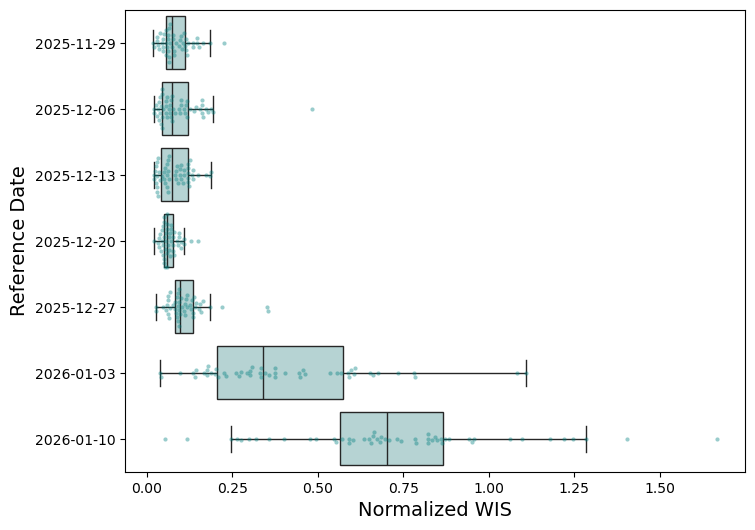

In [78]:
df = WISall.sort_values(by='reference_date')


fig, ax = plt.subplots(1,1,figsize=(8,6))
sns.boxplot(x='WIS_norm', y='reference_date', data=df, orient='h',showfliers=False, color='teal')

for patch in ax.patches:
    r, gr, b, a = patch.get_facecolor()
    patch.set_facecolor((r, gr, b, .3))
    
sns.swarmplot(x='WIS_norm', y='reference_date', data=df,color = 'teal',alpha = .4,size=3,
              orient="h")  


plt.xlabel('Normalized WIS', fontsize=14)
plt.ylabel('Reference Date', fontsize=14)